EDGE-AWARE IMAGE FUSION PIPELINE

Analyzing Image characteristics

Image 1:
  Structure - Edge Strength: 58.58, Contrast: 21.89, Sharpness: 10.09
  Appearance - Saturation: 119.25, Brightness: 118.37, Color Var: 86.03

Image 2:
  Structure - Edge Strength: 43.97, Contrast: 17.99, Sharpness: 8.04
  Appearance - Saturation: 194.26, Brightness: 97.36, Color Var: 78.87

=> Structure: Image 1 is sharper
=> Appearance: Image 2 has richer colors

Stage 1: Graph Cuts Segmentation
Building graph with structure-aware data terms...
Computing min-cut...
Max flow: 56067343.68
Segmentation: 154890 pixels from Image 1, 445878 pixels from Image 2

Stage 2: Poisson Blending
Extracting gradients from selected regions...
  Channel 1/3: Solving 600768x600768 sparse system...
  Channel 2/3: Solving 600768x600768 sparse system...
  Channel 3/3: Solving 600768x600768 sparse system...
Gradients blended successfully!

Stage 3: Guided Filter Refinement
Applying edge-preserving filter (r=8, ε=0.001)...
Edge refi

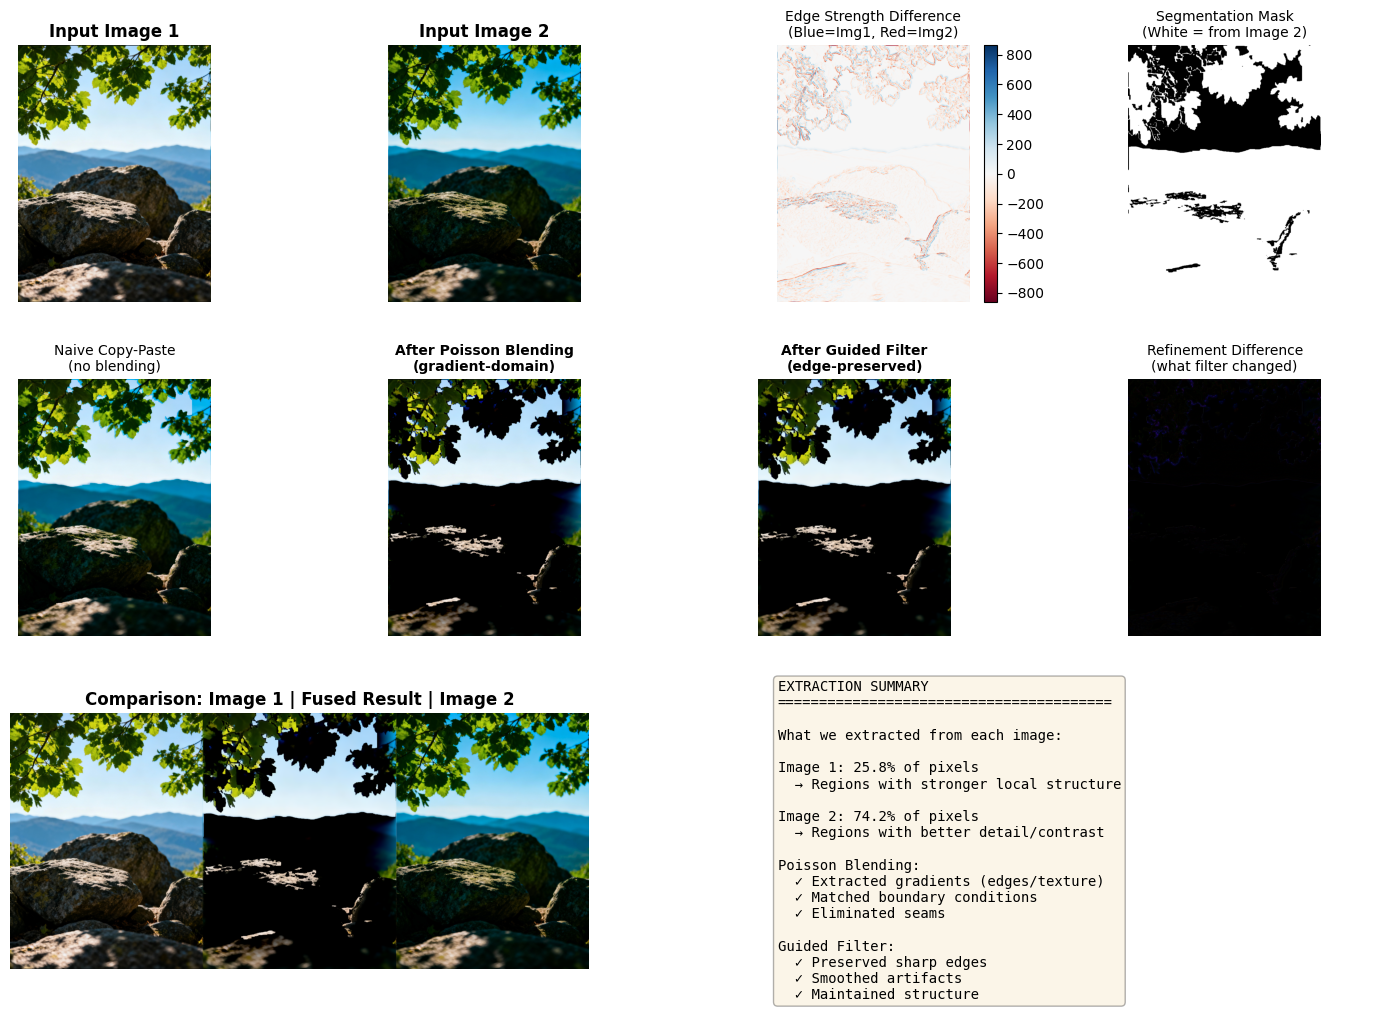

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import maxflow
from typing import Tuple, Dict

class ImageFusionPipeline:
    #edge aware image fusion through intelligent region selection adn gradient blending
    
    def __init__(self, img1_path: str, img2_path: str):
        #initialize with 2 image paths
        self.img1 = cv2.imread("img1.png")
        self.img2 = cv2.imread("img2.png")
        
        if self.img1 is None or self.img2 is None:
            raise ValueError("Could not read one or both images")
        
        #resizing
        if self.img1.shape != self.img2.shape:
            h, w = min(self.img1.shape[0], self.img2.shape[0]), min(self.img1.shape[1], self.img2.shape[1])
            self.img1 = cv2.resize(self.img1, (w, h))
            self.img2 = cv2.resize(self.img2, (w, h))
        
        self.img1_rgb = cv2.cvtColor(self.img1, cv2.COLOR_BGR2RGB)
        self.img2_rgb = cv2.cvtColor(self.img2, cv2.COLOR_BGR2RGB)
        
        #analysis results
        self.analysis = None
        self.mask = None
        self.blended = None
        self.refined = None
    
    def analyze_images(self) -> Dict:
        print("\nAnalyzing Image characteristics")
        
        #convert to grayscale for structure analysis
        gray1 = cv2.cvtColor(self.img1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(self.img2, cv2.COLOR_BGR2GRAY)
        
        #edge strength and local contrast
        #sobel gradients for edge detection
        sobelx1 = cv2.Sobel(gray1, cv2.CV_64F, 1, 0, ksize=3)
        sobely1 = cv2.Sobel(gray1, cv2.CV_64F, 0, 1, ksize=3)
        edge_mag1 = np.sqrt(sobelx1**2 + sobely1**2)
        
        sobelx2 = cv2.Sobel(gray2, cv2.CV_64F, 1, 0, ksize=3)
        sobely2 = cv2.Sobel(gray2, cv2.CV_64F, 0, 1, ksize=3)
        edge_mag2 = np.sqrt(sobelx2**2 + sobely2**2)
        
        #local contrast using Laplacian
        lap1 = cv2.Laplacian(gray1, cv2.CV_64F)
        lap2 = cv2.Laplacian(gray2, cv2.CV_64F)
        
        #structure metrics
        edge_strength1 = np.mean(edge_mag1)
        edge_strength2 = np.mean(edge_mag2)
        contrast1 = np.std(lap1)
        contrast2 = np.std(lap2)
        sharpness1 = np.mean(np.abs(lap1))
        sharpness2 = np.mean(np.abs(lap2))
        
        #convert to HSV for color analysis
        hsv1 = cv2.cvtColor(self.img1, cv2.COLOR_BGR2HSV)
        hsv2 = cv2.cvtColor(self.img2, cv2.COLOR_BGR2HSV)
        
        #color richness (saturation)
        saturation1 = np.mean(hsv1[:, :, 1])
        saturation2 = np.mean(hsv2[:, :, 1])
        
        #brightness
        brightness1 = np.mean(hsv1[:, :, 2])
        brightness2 = np.mean(hsv2[:, :, 2])
        
        #color variance (how varied the colors are)
        color_var1 = np.std(self.img1_rgb, axis=(0, 1)).mean()
        color_var2 = np.std(self.img2_rgb, axis=(0, 1)).mean()
        
        analysis = {
            'edge_strength': (edge_strength1, edge_strength2),
            'contrast': (contrast1, contrast2),
            'sharpness': (sharpness1, sharpness2),
            'saturation': (saturation1, saturation2),
            'brightness': (brightness1, brightness2),
            'color_variance': (color_var1, color_var2),
            'edge_maps': (edge_mag1, edge_mag2),
            'laplacian': (lap1, lap2)
        }
        
        print(f"\nImage 1:")
        print(f"  Structure - Edge Strength: {edge_strength1:.2f}, Contrast: {contrast1:.2f}, Sharpness: {sharpness1:.2f}")
        print(f"  Appearance - Saturation: {saturation1:.2f}, Brightness: {brightness1:.2f}, Color Var: {color_var1:.2f}")
        
        print(f"\nImage 2:")
        print(f"  Structure - Edge Strength: {edge_strength2:.2f}, Contrast: {contrast2:.2f}, Sharpness: {sharpness2:.2f}")
        print(f"  Appearance - Saturation: {saturation2:.2f}, Brightness: {brightness2:.2f}, Color Var: {color_var2:.2f}")
        
        structure_score1 = edge_strength1 + contrast1 + sharpness1
        structure_score2 = edge_strength2 + contrast2 + sharpness2
        
        appearance_score1 = saturation1 + color_var1
        appearance_score2 = saturation2 + color_var2
        
        print(f"\n=> Structure: Image {'1' if structure_score1 > structure_score2 else '2'} is sharper")
        print(f"=> Appearance: Image {'1' if appearance_score1 > appearance_score2 else '2'} has richer colors")
        
        self.analysis = analysis
        return analysis
    
    def segment_graph_cuts(self, connectivity: int = 4, color_space: str = 'RGB') -> np.ndarray:
        h, w = self.img1.shape[:2]
        
        if self.analysis is None:
            self.analyze_images()
        
        print("\nStage 1: Graph Cuts Segmentation")
        print("Building graph with structure-aware data terms...")
        
        #convert to chosen color space
        if color_space == 'HSV':
            img1_cs = cv2.cvtColor(self.img1, cv2.COLOR_BGR2HSV).astype(np.float32)
            img2_cs = cv2.cvtColor(self.img2, cv2.COLOR_BGR2HSV).astype(np.float32)
        elif color_space == 'Lab':
            img1_cs = cv2.cvtColor(self.img1, cv2.COLOR_BGR2Lab).astype(np.float32)
            img2_cs = cv2.cvtColor(self.img2, cv2.COLOR_BGR2Lab).astype(np.float32)
        else:
            img1_cs = self.img1_rgb.astype(np.float32)
            img2_cs = self.img2_rgb.astype(np.float32)
        
        #get local structure quality maps
        edge_mag1, edge_mag2 = self.analysis['edge_maps']
        lap1, lap2 = self.analysis['laplacian']
        
        #normalize edge magnitudes
        edge_mag1_norm = (edge_mag1 - edge_mag1.min()) / (edge_mag1.max() - edge_mag1.min() + 1e-8)
        edge_mag2_norm = (edge_mag2 - edge_mag2.min()) / (edge_mag2.max() - edge_mag2.min() + 1e-8)
        
        #local contrast (absolute Laplacian)
        contrast1 = np.abs(lap1)
        contrast2 = np.abs(lap2)
        contrast1_norm = (contrast1 - contrast1.min()) / (contrast1.max() - contrast1.min() + 1e-8)
        contrast2_norm = (contrast2 - contrast2.min()) / (contrast2.max() - contrast2.min() + 1e-8)
        
        #combined quality score: prefer image with stronger local structure
        quality1 = edge_mag1_norm + contrast1_norm
        quality2 = edge_mag2_norm + contrast2_norm
        
        #create graph
        g = maxflow.Graph[float]()
        nodes = g.add_nodes(h * w)
        
        quality1_flat = quality1.flatten()
        quality2_flat = quality2.flatten()
        
        #normalize and invert (lower quality = higher cost)
        max_quality = max(quality1_flat.max(), quality2_flat.max())
        if max_quality > 0:
            data_cost1 = (1.0 - quality1_flat / max_quality) * 100
            data_cost2 = (1.0 - quality2_flat / max_quality) * 100
        else:
            data_cost1 = np.ones(h * w) * 50
            data_cost2 = np.ones(h * w) * 50
        
        #set terminal edges (source=img1, sink=img2)
        for i in range(h * w):
            g.add_tedge(nodes[i], data_cost1[i], data_cost2[i])

        sigma_color = 30.0
        
        def add_edge(i1, j1, i2, j2):
            #add smoothness edge between neighbours
            if 0 <= i2 < h and 0 <= j2 < w:
                idx1 = i1 * w + j1
                idx2 = i2 * w + j2
                
                #color difference penalty
                color_diff = np.sum((img1_cs[i1, j1] - img1_cs[i2, j2]) ** 2)
                weight = np.exp(-color_diff / (2 * sigma_color ** 2)) * 50
                
                g.add_edge(nodes[idx1], nodes[idx2], weight, weight)
        
        #add neighborhood connections
        for i in range(h):
            for j in range(w):
                add_edge(i, j, i, j+1)
                add_edge(i, j, i+1, j)
                
                if connectivity == 8:
                    add_edge(i, j, i+1, j+1)
                    add_edge(i, j, i+1, j-1)
        
        #compute max-flow/min-cut
        print("Computing min-cut...")
        flow = g.maxflow()
        print(f"Max flow: {flow:.2f}")
        
        #extract segmentation mask
        mask = np.zeros(h * w, dtype=np.uint8)
        for i in range(h * w):
            mask[i] = g.get_segment(nodes[i])
        
        self.mask = mask.reshape(h, w)
        
        #statistics
        pixels_from_img1 = np.sum(self.mask == 0)
        pixels_from_img2 = np.sum(self.mask == 1)
        print(f"Segmentation: {pixels_from_img1} pixels from Image 1, {pixels_from_img2} pixels from Image 2")
        
        return self.mask
    
    def poisson_blend(self, mask: np.ndarray = None) -> np.ndarray:
        if mask is None:
            mask = self.mask
        
        print("\nStage 2: Poisson Blending")
        print("Extracting gradients from selected regions...")
        
        h, w = self.img1_rgb.shape[:2]
        result = np.zeros_like(self.img1_rgb, dtype=np.float32)
        
        #process each color channel
        for c in range(3):
            #source and target
            source = self.img2_rgb[:, :, c].astype(np.float32)
            target = self.img1_rgb[:, :, c].astype(np.float32)
            
            #find region boundary (for boundary conditions)
            mask_dilated = cv2.dilate(mask.astype(np.uint8), np.ones((3,3), np.uint8))
            boundary = (mask_dilated > mask)
            
            #build linear system: match gradients inside mask
            n_pixels = h * w
            A = lil_matrix((n_pixels, n_pixels))
            b = np.zeros(n_pixels)
            
            for i in range(h):
                for j in range(w):
                    idx = i * w + j
                    
                    if mask[i, j]:  #inside selected region
                        A[idx, idx] = 4
                        
                        guidance = 4 * source[i, j]
                        
                        for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                            ni, nj = i + di, j + dj
                            if 0 <= ni < h and 0 <= nj < w:
                                nidx = ni * w + nj
                                
                                if mask[ni, nj]:
                                    A[idx, nidx] = -1
                                    guidance -= source[ni, nj]
                                else:
                                    guidance -= target[ni, nj]
                        
                        b[idx] = guidance
                    
                    else:
                        A[idx, idx] = 1
                        b[idx] = target[i, j]
            
            print(f"  Channel {c+1}/3: Solving {n_pixels}x{n_pixels} sparse system...")
            A_csr = A.tocsr()
            result_channel = spsolve(A_csr, b)
            result[:, :, c] = result_channel.reshape(h, w)
        
        result = np.clip(result, 0, 255).astype(np.uint8)
        self.blended = result
        
        print("Gradients blended successfully!")
        return result
    
    def guided_filter(self, image: np.ndarray, radius: int = 8, eps: float = 1e-3) -> np.ndarray:
        print("\nStage 3: Guided Filter Refinement")
        print(f"Applying edge-preserving filter (r={radius}, ε={eps})...")
        
        guide = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
        
        result = np.zeros_like(image, dtype=np.float32)
        
        for c in range(3):
            p = image[:, :, c].astype(np.float32) / 255.0
            
            mean_I = cv2.boxFilter(guide, -1, (radius, radius))
            mean_p = cv2.boxFilter(p, -1, (radius, radius))
            mean_Ip = cv2.boxFilter(guide * p, -1, (radius, radius))
            
            cov_Ip = mean_Ip - mean_I * mean_p
            mean_II = cv2.boxFilter(guide * guide, -1, (radius, radius))
            var_I = mean_II - mean_I * mean_I
            
            a = cov_Ip / (var_I + eps)
            b = mean_p - a * mean_I
            
            mean_a = cv2.boxFilter(a, -1, (radius, radius))
            mean_b = cv2.boxFilter(b, -1, (radius, radius))
            
            q = mean_a * guide + mean_b
            result[:, :, c] = q * 255.0
        
        result = np.clip(result, 0, 255).astype(np.uint8)
        self.refined = result
        
        print("Edge refinement complete!")
        return result
    
    def run_pipeline(self, connectivity: int = 4, color_space: str = 'RGB',
                     filter_radius: int = 8, filter_eps: float = 1e-3):
        print("EDGE-AWARE IMAGE FUSION PIPELINE")
        
        self.analyze_images()
        
        self.segment_graph_cuts(connectivity, color_space)
        
        self.poisson_blend()
        
        self.guided_filter(self.blended, filter_radius, filter_eps)
        
        self.visualize_pipeline()
    
    def visualize_pipeline(self):
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
        
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(self.img1_rgb)
        ax1.set_title('Input Image 1', fontsize=12, fontweight='bold')
        ax1.axis('off')
        
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.imshow(self.img2_rgb)
        ax2.set_title('Input Image 2', fontsize=12, fontweight='bold')
        ax2.axis('off')
        
        ax3 = fig.add_subplot(gs[0, 2])
        edge_mag1, edge_mag2 = self.analysis['edge_maps']
        edge_diff = edge_mag2 - edge_mag1
        im3 = ax3.imshow(edge_diff, cmap='RdBu', vmin=-np.abs(edge_diff).max(), vmax=np.abs(edge_diff).max())
        ax3.set_title('Edge Strength Difference\n(Blue=Img1, Red=Img2)', fontsize=10)
        ax3.axis('off')
        plt.colorbar(im3, ax=ax3, fraction=0.046)
        
        ax4 = fig.add_subplot(gs[0, 3])
        ax4.imshow(self.mask, cmap='gray')
        ax4.set_title('Segmentation Mask\n(White = from Image 2)', fontsize=10)
        ax4.axis('off')
        
        ax5 = fig.add_subplot(gs[1, 0])
        naive = self.img1_rgb.copy()
        naive[self.mask == 1] = self.img2_rgb[self.mask == 1]
        ax5.imshow(naive)
        ax5.set_title('Naive Copy-Paste\n(no blending)', fontsize=10)
        ax5.axis('off')
        
        ax6 = fig.add_subplot(gs[1, 1])
        ax6.imshow(self.blended)
        ax6.set_title('After Poisson Blending\n(gradient-domain)', fontsize=10, fontweight='bold')
        ax6.axis('off')
        
        ax7 = fig.add_subplot(gs[1, 2])
        ax7.imshow(self.refined)
        ax7.set_title('After Guided Filter\n(edge-preserved)', fontsize=10, fontweight='bold')
        ax7.axis('off')
        
        ax8 = fig.add_subplot(gs[1, 3])
        diff = cv2.absdiff(self.blended, self.refined)
        ax8.imshow(diff)
        ax8.set_title('Refinement Difference\n(what filter changed)', fontsize=10)
        ax8.axis('off')
        
        ax9 = fig.add_subplot(gs[2, :2])
        comparison = np.hstack([self.img1_rgb, self.refined, self.img2_rgb])
        ax9.imshow(comparison)
        ax9.set_title('Comparison: Image 1 | Fused Result | Image 2', fontsize=12, fontweight='bold')
        ax9.axis('off')
        cv2.imwrite('fused_result.png', cv2.cvtColor(self.refined, cv2.COLOR_RGB2BGR))
        cv2.imwrite('fused_result_brightened.png', cv2.cvtColor(np.clip(self.refined+10, 0, 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
        
        ax10 = fig.add_subplot(gs[2, 2:])
        ax10.axis('off')
        
        stats_text = "EXTRACTION SUMMARY\n" + "="*40 + "\n\n"
        stats_text += "What we extracted from each image:\n\n"
        
        pixels_from_1 = np.sum(self.mask == 0)
        pixels_from_2 = np.sum(self.mask == 1)
        total = self.mask.size
        
        stats_text += f"Image 1: {pixels_from_1/total*100:.1f}% of pixels\n"
        stats_text += f"  → Regions with stronger local structure\n\n"
        
        stats_text += f"Image 2: {pixels_from_2/total*100:.1f}% of pixels\n"
        stats_text += f"  → Regions with better detail/contrast\n\n"
        
        stats_text += "Poisson Blending:\n"
        stats_text += f"  ✓ Extracted gradients (edges/texture)\n"
        stats_text += f"  ✓ Matched boundary conditions\n"
        stats_text += f"  ✓ Eliminated seams\n\n"
        
        stats_text += "Guided Filter:\n"
        stats_text += f"  ✓ Preserved sharp edges\n"
        stats_text += f"  ✓ Smoothed artifacts\n"
        stats_text += f"  ✓ Maintained structure"
        
        ax10.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                 verticalalignment='center', bbox=dict(boxstyle='round', 
                 facecolor='wheat', alpha=0.3))
        
        plt.savefig('fusion_pipeline_detailed.png', dpi=200, bbox_inches='tight')
        print("\n" + "="*60)
        print("✓ Pipeline complete!")
        print("✓ Output saved as 'fusion_pipeline_detailed.png'")
        print("="*60 + "\n")
        plt.show()

if __name__ == "__main__":
    img1_path = "image1.jpg"
    img2_path = "image2.jpg"
    
    try:
        pipeline = ImageFusionPipeline(img1_path, img2_path)
        pipeline.run_pipeline(
            connectivity=4,
            color_space='RGB',
            filter_radius=8,
            filter_eps=1e-3
        )
    except Exception as e:
        print(f"Error: {e}")
        print("\nPlease provide two image paths to fuse.")